# MSAI-699 Capstone — Week 3: Baseline Model Implementation
**Student:** Prashant Sharma  
**Dataset:** UCI Heart Disease (Cleveland + Hungarian + Switzerland)  
**Project Context:** Baseline for 30-Day Hospital Readmission Prediction  
**Models:** Logistic Regression (baseline) + XGBoost (enhanced baseline)

## 1. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
import xgboost as xgb

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load & Merge Datasets

We combine the three processed UCI Heart Disease files (Cleveland, Hungarian, Switzerland).
Each has 13 features + 1 target (0 = no disease, 1-4 = severity levels).

In [4]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

DATA_FILES = [
    'processed.cleveland.data',
    'processed.hungarian.data',
    'processed.switzerland.data',
]

dfs = []
for f in DATA_FILES:
    d = pd.read_csv(f, header=None, names=cols, na_values='?')
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print(f'Combined shape: {df.shape}')
df.head()

Combined shape: (720, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Exploratory Data Analysis

In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Missing Values ===
age           0
sex           0
cp            0
trestbps      3
chol         23
fbs          83
restecg       2
thalach       2
exang         2
oldpeak       6
slope       207
ca          413
thal        320
target        0
dtype: int64

Total missing: 1061


In [6]:
print('=== Target Distribution (raw) ===')
print(df['target'].value_counts())

# Binarize: 0 = no disease, 1 = disease
df['target'] = (df['target'] > 0).astype(int)
print('\n=== Binary Target ===')
print(df['target'].value_counts())
print(f'\nClass balance: {df["target"].mean():.1%} positive (disease)')

=== Target Distribution (raw) ===
target
0    360
1    209
2     68
3     65
4     18
Name: count, dtype: int64

=== Binary Target ===
target
0    360
1    360
Name: count, dtype: int64

Class balance: 50.0% positive (disease)


In [7]:
print(df.describe().round(2))

          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  720.00  720.00  720.00    717.00  697.00  637.00   718.00   718.00   
mean    51.89    0.74    3.18    131.80  204.77    0.11     0.57   140.57   
std      9.19    0.44    0.95     18.53  109.28    0.31     0.83    25.65   
min     28.00    0.00    1.00     80.00    0.00    0.00     0.00    60.00   
25%     45.00    0.00    2.00    120.00  182.00    0.00     0.00   122.00   
50%     53.00    1.00    4.00    130.00  227.00    0.00     0.00   142.00   
75%     58.00    1.00    4.00    140.00  270.00    0.00     1.00   160.00   
max     77.00    1.00    4.00    200.00  603.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  718.00   714.00  513.00  307.00  400.00   720.0  
mean     0.34     0.79    1.70    0.68    4.99     0.5  
std      0.47     1.07    0.59    0.94    1.93     0.5  
min      0.00    -2.60    1.00    0.00    3.00     0.0  
25%      0.00     0.0

## 4. Preprocessing

In [8]:
# Median imputation for missing values
df = df.fillna(df.median(numeric_only=True))
print(f'Missing after imputation: {df.isnull().sum().sum()}')

X = df.drop('target', axis=1)
y = df['target']
feature_names = X.columns.tolist()

# Train/test split (stratified, time-agnostic for this dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.1%}')
print(f'Test positive rate:  {y_test.mean():.1%}')

Missing after imputation: 0
Train: (576, 13), Test: (144, 13)
Train positive rate: 50.0%
Test positive rate:  50.0%


## 5. Model 1: Logistic Regression (Baseline)

Logistic Regression serves as the interpretable baseline, analogous to the LACE index approach used in clinical readmission prediction.

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_pred  = lr.predict(X_test_sc)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
lr_f1  = f1_score(y_test, lr_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print(f'AUC-ROC : {lr_auc:.4f}')
print(f'F1 Score: {lr_f1:.4f}')
print(f'Accuracy: {lr_acc:.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

AUC-ROC : 0.8902
F1 Score: 0.8310
Accuracy: 0.8333

              precision    recall  f1-score   support

  No Disease       0.82      0.85      0.84        72
     Disease       0.84      0.82      0.83        72

    accuracy                           0.83       144
   macro avg       0.83      0.83      0.83       144
weighted avg       0.83      0.83      0.83       144



In [10]:
# 5-fold cross-validation
cv_lr = cross_validate(lr, X_train_sc, y_train, cv=5,
                       scoring=['roc_auc', 'f1', 'accuracy'])
print(f'CV AUC:  {cv_lr["test_roc_auc"].mean():.4f} +/- {cv_lr["test_roc_auc"].std():.4f}')
print(f'CV F1:   {cv_lr["test_f1"].mean():.4f} +/- {cv_lr["test_f1"].std():.4f}')
print(f'CV Acc:  {cv_lr["test_accuracy"].mean():.4f} +/- {cv_lr["test_accuracy"].std():.4f}')

CV AUC:  0.8972 +/- 0.0174
CV F1:   0.8306 +/- 0.0205
CV Acc:  0.8333 +/- 0.0179


In [11]:
# Logistic Regression Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

 Feature  Coefficient
      ca     0.771109
    chol    -0.668985
      cp     0.655572
   exang     0.586319
 oldpeak     0.477399
    thal     0.473117
     sex     0.427272
 thalach    -0.414252
     age     0.179058
 restecg     0.170197
trestbps     0.153419
   slope     0.131111
     fbs    -0.063197


## 6. Model 2: XGBoost (Enhanced Baseline)

XGBoost is the primary model for the capstone project. It handles non-linear relationships, missing data, and mixed feature types without requiring scaling.

In [12]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_f1  = f1_score(y_test, xgb_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f'AUC-ROC : {xgb_auc:.4f}')
print(f'F1 Score: {xgb_f1:.4f}')
print(f'Accuracy: {xgb_acc:.4f}')
print()
print(classification_report(y_test, xgb_pred, target_names=['No Disease', 'Disease']))

AUC-ROC : 0.9055
F1 Score: 0.8472
Accuracy: 0.8472

              precision    recall  f1-score   support

  No Disease       0.85      0.85      0.85        72
     Disease       0.85      0.85      0.85        72

    accuracy                           0.85       144
   macro avg       0.85      0.85      0.85       144
weighted avg       0.85      0.85      0.85       144



In [13]:
# 5-fold cross-validation
cv_xgb = cross_validate(xgb_model, X, y, cv=5,
                        scoring=['roc_auc', 'f1', 'accuracy'])
print(f'CV AUC:  {cv_xgb["test_roc_auc"].mean():.4f} +/- {cv_xgb["test_roc_auc"].std():.4f}')
print(f'CV F1:   {cv_xgb["test_f1"].mean():.4f} +/- {cv_xgb["test_f1"].std():.4f}')
print(f'CV Acc:  {cv_xgb["test_accuracy"].mean():.4f} +/- {cv_xgb["test_accuracy"].std():.4f}')

CV AUC:  0.8658 +/- 0.0671
CV F1:   0.7760 +/- 0.0669
CV Acc:  0.7806 +/- 0.0498


## 7. Feature Importance

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/feature_importance.png'

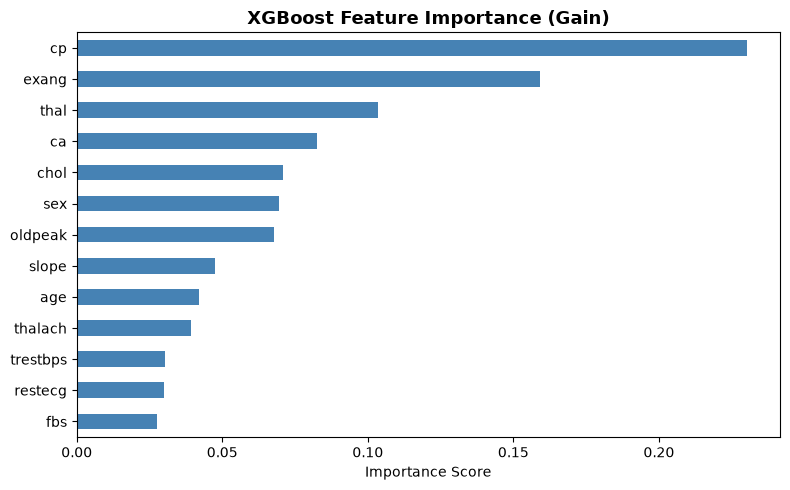

In [14]:
fi = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(fi.sort_values(ascending=False))

## 8. ROC Curve Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, lr_proba, name=f'Logistic Regression (AUC={lr_auc:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name=f'XGBoost (AUC={xgb_auc:.3f})', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curve: Logistic Regression vs XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Results Summary

In [ ]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Test AUC': [lr_auc, xgb_auc],
    'Test F1': [lr_f1, xgb_f1],
    'Test Accuracy': [lr_acc, xgb_acc],
    'CV AUC Mean': [cv_lr['test_roc_auc'].mean(), cv_xgb['test_roc_auc'].mean()],
    'CV AUC Std': [cv_lr['test_roc_auc'].std(), cv_xgb['test_roc_auc'].std()],
}).round(4)
print(results.to_string(index=False))

## 10. Next Steps

1. **Hyperparameter tuning** using Optuna (Week 4)
2. **SHAP explainability** with updated shap/xgboost versions
3. **Migrate to MIMIC-III** once PhysioNet access is approved
4. **Add NLP features** from discharge summaries via ClinicalBERT
5. **Class imbalance handling** via SMOTE or class weighting on MIMIC data
6. **Fairness audit** across demographic subgroups